This dataset is from https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

Additional Information

We use 24 + class = 25 ( 11  numeric ,14  nominal)


1.Age(numerical)  	  	age in years

2.Blood Pressure(numerical)	       	bp in mm/Hg

3.Specific Gravity(nominal)	  	sg - (1.005,1.010,1.015,1.020,1.025)

4.Albumin(nominal)		al - (0,1,2,3,4,5)

5.Sugar(nominal)		su - (0,1,2,3,4,5)

6.Red Blood Cells(nominal)	rbc - (normal,abnormal)

7.Pus Cell (nominal)		pc - (normal,abnormal)
 	
8.Pus Cell clumps(nominal)		pcc - (present,notpresent)
 	
9.Bacteria(nominal)		ba  - (present,notpresent)

10.Blood Glucose Random(numerical)				bgr in mgs/dl

11.Blood Urea(numerical)			bu in mgs/dl

12.Serum Creatinine(numerical)			sc in mgs/dl

13.Sodium(numerical)		sod in mEq/L

14.Potassium(numerical)			pot in mEq/L

15.Hemoglobin(numerical)		hemo in gms

16.Packed  Cell Volume(numerical) 	

17.White Blood Cell Count(numerical)		wc in cells/cumm
 	
18.Red Blood Cell Count(numerical)			rc in millions/cmm

19.Hypertension(nominal)			htn - (yes,no)

20.Diabetes Mellitus(nominal)			dm - (yes,no)

21.Coronary Artery Disease(nominal)		cad - (yes,no)

22.Appetite(nominal)			appet - (good,poor)

23.Pedal Edema(nominal)		pe - (yes,no)	

24.Anemia(nominal)		ane - (yes,no)

25.Class (nominal)		class - (ckd,notckd)

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('kidney_disease.csv')

In [3]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [4]:
df.columns = [
    'id','age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
    'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
    'potassium', 'hemoglobin', 'packed_cell_volume', 'white_blood_cell_count',
    'red_blood_cell_count', 'hypertension', 'diabetes_mellitus',
    'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia', 'class'
]

In [5]:
df.head()

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      391 non-null    float64
 2   blood_pressure           388 non-null    float64
 3   specific_gravity         353 non-null    float64
 4   albumin                  354 non-null    float64
 5   sugar                    351 non-null    float64
 6   red_blood_cells          248 non-null    object 
 7   pus_cell                 335 non-null    object 
 8   pus_cell_clumps          396 non-null    object 
 9   bacteria                 396 non-null    object 
 10  blood_glucose_random     356 non-null    float64
 11  blood_urea               381 non-null    float64
 12  serum_creatinine         383 non-null    float64
 13  sodium                   313 non-null    float64
 14  potassium                3

In [7]:
# Calculate the proportion of CKD patients
ckd_proportion = sum(df['class'] == 'ckd')*100 / len(df)
print('Proportion of CKD patients:',sum(df['class'] == 'ckd') ,', ',ckd_proportion,'%')

# Calculate the proportion of non-CKD patients
non_ckd_proportion = sum(df['class'] != 'ckd')*100 / len(df)
print('Proportion of non-CKD patients:',sum(df['class'] != 'ckd'),', ',non_ckd_proportion,'%')

Proportion of CKD patients: 248 ,  62.0 %
Proportion of non-CKD patients: 152 ,  38.0 %


In [8]:
# Convert numerical columns to numeric data type
numeric_cols = [
    'age', 'blood_pressure','specific_gravity', 'albumin','sugar', 'blood_glucose_random', 'blood_urea',
    'serum_creatinine', 'sodium', 'potassium', 'hemoglobin',
    'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count'
]

In [9]:
def str_col(df, numeric_cols):
    lst = []
    for var in df.columns:
        if var not in numeric_cols:
            lst.append(var)
    return lst

In [10]:
string_cols = str_col(df, numeric_cols)[1:]

In [11]:
_ = [print(col, df[col].unique()) for col in df]

id [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245

In [12]:
#replace abnormal values
replace_t = {'\t':np.nan,'\t?':np.nan,'\t43':'43','\t6200':'6200','\t8400':'8400',' yes':'yes','\tyes':'yes','\tno':'no','ckd\t':'ckd'}
_ = [print(col, df.replace(replace_t)[col].unique()) for col in df.replace(replace_t)]

id [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245

In [13]:
#drop id columns because it is not essential.
df.drop('id',axis=1,inplace=True)

In [14]:
df = df.replace(replace_t)

In [15]:
_ = [print(col, df[col].unique()) for col in df]

age [48.  7. 62. 51. 60. 68. 24. 52. 53. 50. 63. 40. 47. 61. 21. 42. 75. 69.
 nan 73. 70. 65. 76. 72. 82. 46. 45. 35. 54. 11. 59. 67. 15. 55. 44. 26.
 64. 56.  5. 74. 38. 58. 71. 34. 17. 12. 43. 41. 57.  8. 39. 66. 81. 14.
 27. 83. 30.  4.  3.  6. 32. 80. 49. 90. 78. 19.  2. 33. 36. 37. 23. 25.
 20. 29. 28. 22. 79.]
blood_pressure [ 80.  50.  70.  90.  nan 100.  60. 110. 140. 180. 120.]
specific_gravity [1.02  1.01  1.005 1.015   nan 1.025]
albumin [ 1.  4.  2.  3.  0. nan  5.]
sugar [ 0.  3.  4.  1. nan  2.  5.]
red_blood_cells [nan 'normal' 'abnormal']
pus_cell ['normal' 'abnormal' nan]
pus_cell_clumps ['notpresent' 'present' nan]
bacteria ['notpresent' 'present' nan]
blood_glucose_random [121.  nan 423. 117. 106.  74. 100. 410. 138.  70. 490. 380. 208.  98.
 157.  76.  99. 114. 263. 173.  95. 108. 156. 264. 123.  93. 107. 159.
 140. 171. 270.  92. 137. 204.  79. 207. 124. 144.  91. 162. 246. 253.
 141. 182.  86. 150. 146. 425. 112. 250. 360. 163. 129. 133. 102. 158.
 165. 132. 104. 

In [16]:
df[numeric_cols].head()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6


In [17]:
df[string_cols].head()

,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,NaN,normal,notpresent,notpresent,yes,yes,no,good,no,no,ckd
1,NaN,normal,notpresent,notpresent,no,no,no,good,no,no,ckd
2,normal,normal,notpresent,notpresent,no,yes,no,poor,no,yes,ckd
3,normal,abnormal,present,notpresent,yes,no,no,poor,yes,yes,ckd
4,normal,normal,notpresent,notpresent,no,no,no,good,no,no,ckd


In [18]:
cat = {'normal':1,'abnormal':0,'present':1,'notpresent':0,'yes':1,'no':0,'good':1,'poor':0,'ckd':1,'notckd':0}

In [19]:
df = df.applymap(lambda x: cat.get(x, x))

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    float64
 6   pus_cell                 335 non-null    float64
 7   pus_cell_clumps          396 non-null    float64
 8   bacteria                 396 non-null    float64
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

In [21]:
for column in df:
    if df[column].dtype == object:
        df[column] = df[column].astype(float)


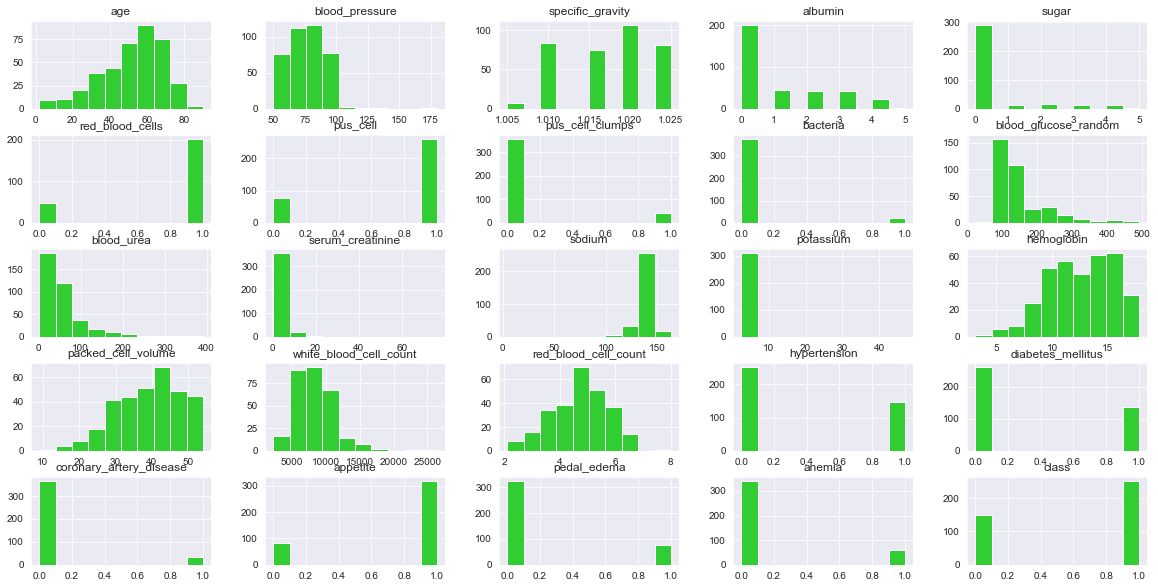

In [22]:
import matplotlib.pyplot as plt

#Find the distribution of features
#Create a histogram
df.hist(figsize=(20,10),color='limegreen')
#Save the plot
_=plt.savefig('image1.jpg')
# Display the plot
plt.show()

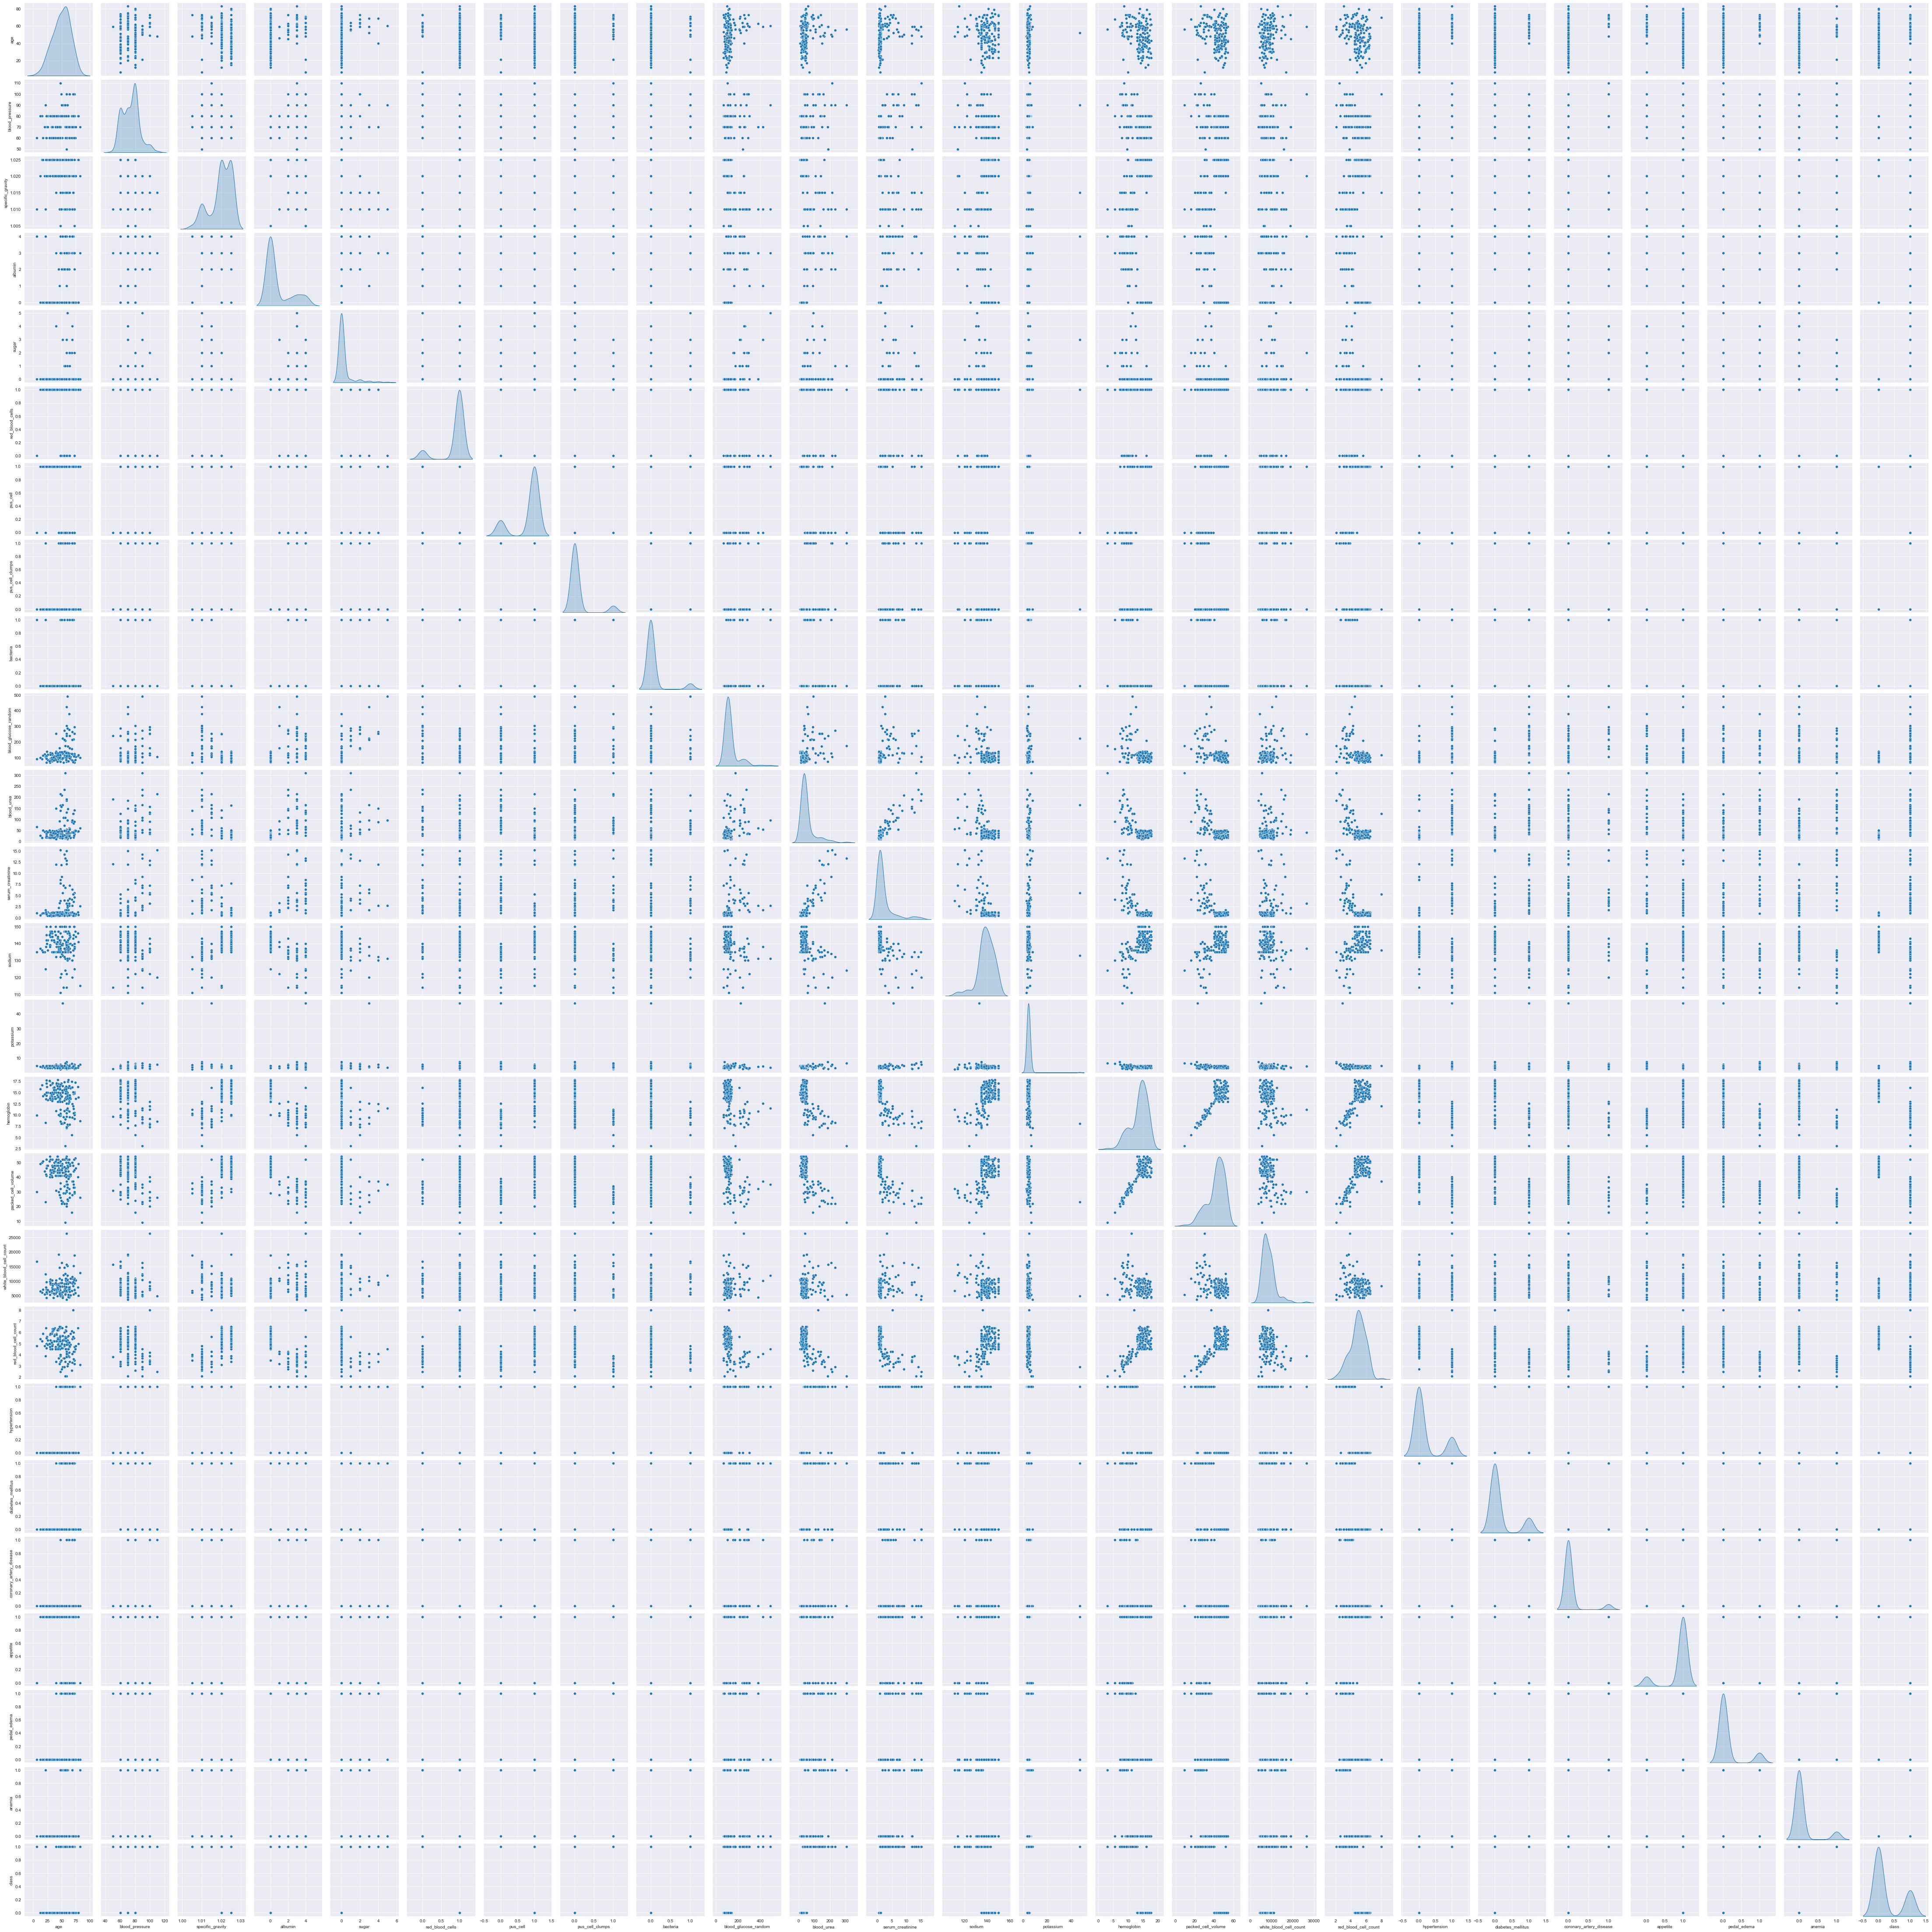

In [24]:
# Create a pairwise scatter plot matrix
import seaborn as sns
sns.pairplot(df.dropna(), diag_kind='kde')
plt.show()

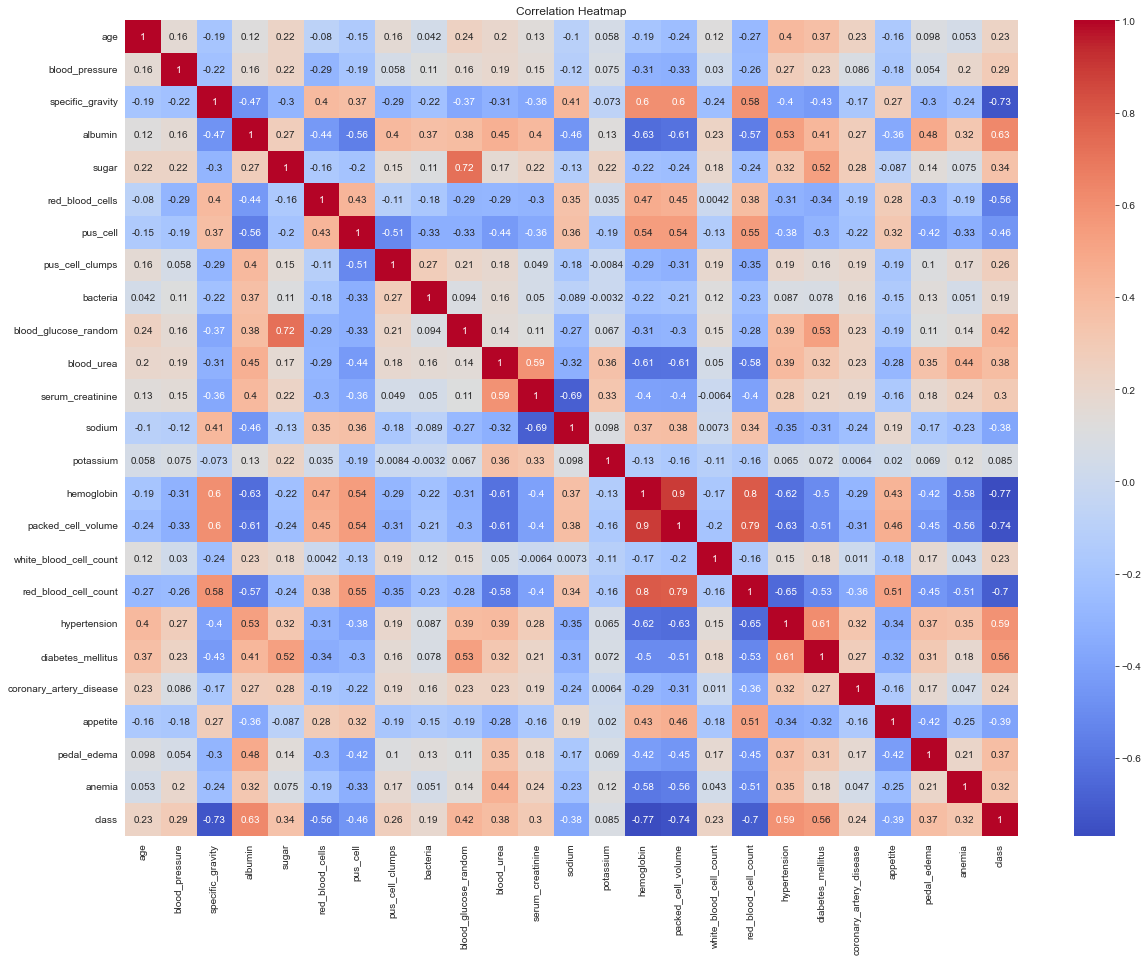

In [26]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create correlation heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()